# Notebook 3: Anomaly Detection — Isolation Forest Claims Scoring
**Project:** Ontario Insurance Claims Intelligence Platform  
**Goal:** Score every claim 0–1 for suspicion. Validate against the fraud_reported label.
Build a ranked suspicious claims queue the investigations team can action.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.gridspec as gridspec

def find_project_root():
    candidates = []
    vsc_path = globals().get('__vsc_ipynb_file__')
    if vsc_path:
        candidates.append(Path(vsc_path).parent)
    candidates.append(Path.cwd())
    for start in candidates:
        for folder in [start] + list(start.parents):
            if (folder / 'requirements.txt').exists():
                return folder
    raise FileNotFoundError("Cannot find project root — is requirements.txt missing?")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

PROCESSED_DATA = PROJECT_ROOT / 'data' / 'processed' / 'insurance_claims_clean.csv'
FIGURES        = PROJECT_ROOT / 'outputs' / 'figures'
REPORTS        = PROJECT_ROOT / 'outputs' / 'reports'
FIGURES.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA)
print(f"Loaded: {df.shape[0]:,} claims, {df.shape[1]} columns")
print(f"Known fraud cases: {df['fraud_reported'].sum()} ({df['fraud_reported'].mean()*100:.1f}%)")

Loaded: 1,000 claims, 45 columns
Known fraud cases: 247 (24.7%)


## Step 1: Feature Engineering for Anomaly Detection

Isolation Forest works on numbers only. We engineer features that capture
the red flags a human investigator would look for:
- Unusually high claim amounts relative to the policy premium
- Multiple vehicles involved
- No police report despite serious damage
- Claim filed late after incident
- High bodily injury counts with no witnesses

In [2]:
def engineer_features(df):
    features = df.copy()
    
    # Feature 1: Claim-to-premium ratio (high = suspicious)
    features['claim_to_premium'] = features['total_claim_amount'] / features['policy_annual_premium']
    
    # Feature 2: Injury-to-vehicle claim ratio (high = suspicious — inflating medical claims)
    features['injury_to_vehicle_ratio'] = features['injury_claim'] / (features['vehicle_claim'] + 1)
    
    # Feature 3: High bodily injuries with no witnesses (suspicious combination)
    features['injuries_no_witnesses'] = (
        features['bodily_injuries'] * (features['witnesses'] == 0).astype(int)
    )
    
    # Feature 4: Serious damage but no police report
    severity_map = {'Minor Damage': 1, 'Major Damage': 2, 'Total Loss': 3, 'Trivial Damage': 0}
    features['severity_score'] = features['incident_severity'].map(severity_map).fillna(1)
    features['no_police_serious'] = (
        features['severity_score'] >= 2) & (features['police_report_available'] != 'YES'
    ).astype(int)
    
    # Feature 5: Number of vehicles involved (more = higher fraud risk for staged accidents)
    features['vehicles_involved'] = features['number_of_vehicles_involved']
    
    # Feature 6: Policy age at incident (very new policies that file large claims are suspicious)
    features['policy_age_days'] = features['policy_age_days'].fillna(features['policy_age_days'].median())
    
    # Feature 7: Claim amount relative to vehicle age (claiming more than car is worth)
    features['claim_per_vehicle_age'] = features['total_claim_amount'] / (features['vehicle_age'] + 1)
    
    # Feature 8: Umbrella limit (high limits on cheap cars = suspicious)
    features['umbrella_limit'] = features['umbrella_limit'].fillna(0)
    
    return features

df_feat = engineer_features(df)

feature_cols = [
    'claim_to_premium',
    'injury_to_vehicle_ratio', 
    'injuries_no_witnesses',
    'severity_score',
    'no_police_serious',
    'vehicles_involved',
    'policy_age_days',
    'claim_per_vehicle_age',
    'total_claim_amount',
    'bodily_injuries',
    'witnesses',
    'umbrella_limit'
]

print(f"Features engineered: {len(feature_cols)}")
print("\nFeature summary:")
print(df_feat[feature_cols].describe().round(2))

Features engineered: 12

Feature summary:
       claim_to_premium  injury_to_vehicle_ratio  injuries_no_witnesses  \
count           1000.00                  1000.00                1000.00   
mean              43.77                     0.20                   0.24   
std               24.64                     0.08                   0.59   
min                0.07                     0.00                   0.00   
25%               32.35                     0.12                   0.00   
50%               44.98                     0.17                   0.00   
75%               58.69                     0.25                   0.00   
max              157.99                     0.50                   2.00   

       severity_score  vehicles_involved  policy_age_days  \
count         1000.00            1000.00          1000.00   
mean             1.75               1.84          4739.14   
std              0.96               1.02          2686.43   
min              0.00               1.

## Step 2: Train the Isolation Forest

Isolation Forest works by randomly partitioning data. Anomalies are isolated
in fewer splits — they get an anomaly score closer to 1.
We set contamination=0.25 because our dataset has ~24.7% known fraud.

In [3]:
# Prepare feature matrix
X = df_feat[feature_cols].copy()

# Scale features so no single feature dominates
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
# contamination = expected proportion of anomalies (we know it's ~24.7%)
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.247,
    random_state=42,
    max_samples='auto'
)

iso_forest.fit(X_scaled)

# Get anomaly scores — raw_score_samples gives continuous scores
# More negative = more anomalous. We flip and normalise to 0-1.
raw_scores = iso_forest.score_samples(X_scaled)
anomaly_scores = 1 - (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())

df['anomaly_score'] = anomaly_scores
df['anomaly_flag']  = iso_forest.predict(X_scaled)
df['anomaly_flag']  = (df['anomaly_flag'] == -1).astype(int)  # -1=anomaly → 1, 1=normal → 0

print(f"Claims flagged as anomalous: {df['anomaly_flag'].sum()} ({df['anomaly_flag'].mean()*100:.1f}%)")
print(f"Known fraud cases:           {df['fraud_reported'].sum()} ({df['fraud_reported'].mean()*100:.1f}%)")
print(f"\nAnomaly score range: {anomaly_scores.min():.3f} to {anomaly_scores.max():.3f}")
print(f"Avg score — fraudulent claims:   {df[df['fraud_reported']==1]['anomaly_score'].mean():.3f}")
print(f"Avg score — legitimate claims:   {df[df['fraud_reported']==0]['anomaly_score'].mean():.3f}")

Claims flagged as anomalous: 247 (24.7%)
Known fraud cases:           247 (24.7%)

Anomaly score range: 0.000 to 1.000
Avg score — fraudulent claims:   0.409
Avg score — legitimate claims:   0.410


## Step 3: Validate  How Well Did It Find Real Fraud?

In [4]:
print("=" * 55)
print("MODEL VALIDATION AGAINST KNOWN FRAUD LABELS")
print("=" * 55)

print("\nClassification Report:")
print(classification_report(df['fraud_reported'], df['anomaly_flag'],
                             target_names=['Legitimate', 'Fraudulent']))

roc_auc = roc_auc_score(df['fraud_reported'], df['anomaly_score'])
print(f"ROC-AUC Score: {roc_auc:.3f}")
print("(0.5 = random guessing, 1.0 = perfect — anything above 0.65 is useful)")

cm = confusion_matrix(df['fraud_reported'], df['anomaly_flag'])
print(f"\nConfusion Matrix:")
print(f"  True Negatives  (correctly cleared):  {cm[0,0]}")
print(f"  False Positives (wrongly flagged):     {cm[0,1]}")
print(f"  False Negatives (fraud missed):        {cm[1,0]}")
print(f"  True Positives  (fraud caught):        {cm[1,1]}")
print(f"\n  Of {df['fraud_reported'].sum()} known fraudulent claims,")
print(f"  the model caught {cm[1,1]} ({cm[1,1]/df['fraud_reported'].sum()*100:.1f}%)")

MODEL VALIDATION AGAINST KNOWN FRAUD LABELS

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.76      0.76      0.76       753
  Fraudulent       0.26      0.26      0.26       247

    accuracy                           0.63      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.63      0.63      0.63      1000

ROC-AUC Score: 0.497
(0.5 = random guessing, 1.0 = perfect — anything above 0.65 is useful)

Confusion Matrix:
  True Negatives  (correctly cleared):  569
  False Positives (wrongly flagged):     184
  False Negatives (fraud missed):        184
  True Positives  (fraud caught):        63

  Of 247 known fraudulent claims,
  the model caught 63 (25.5%)


## Step 4: Visualise Model Performance

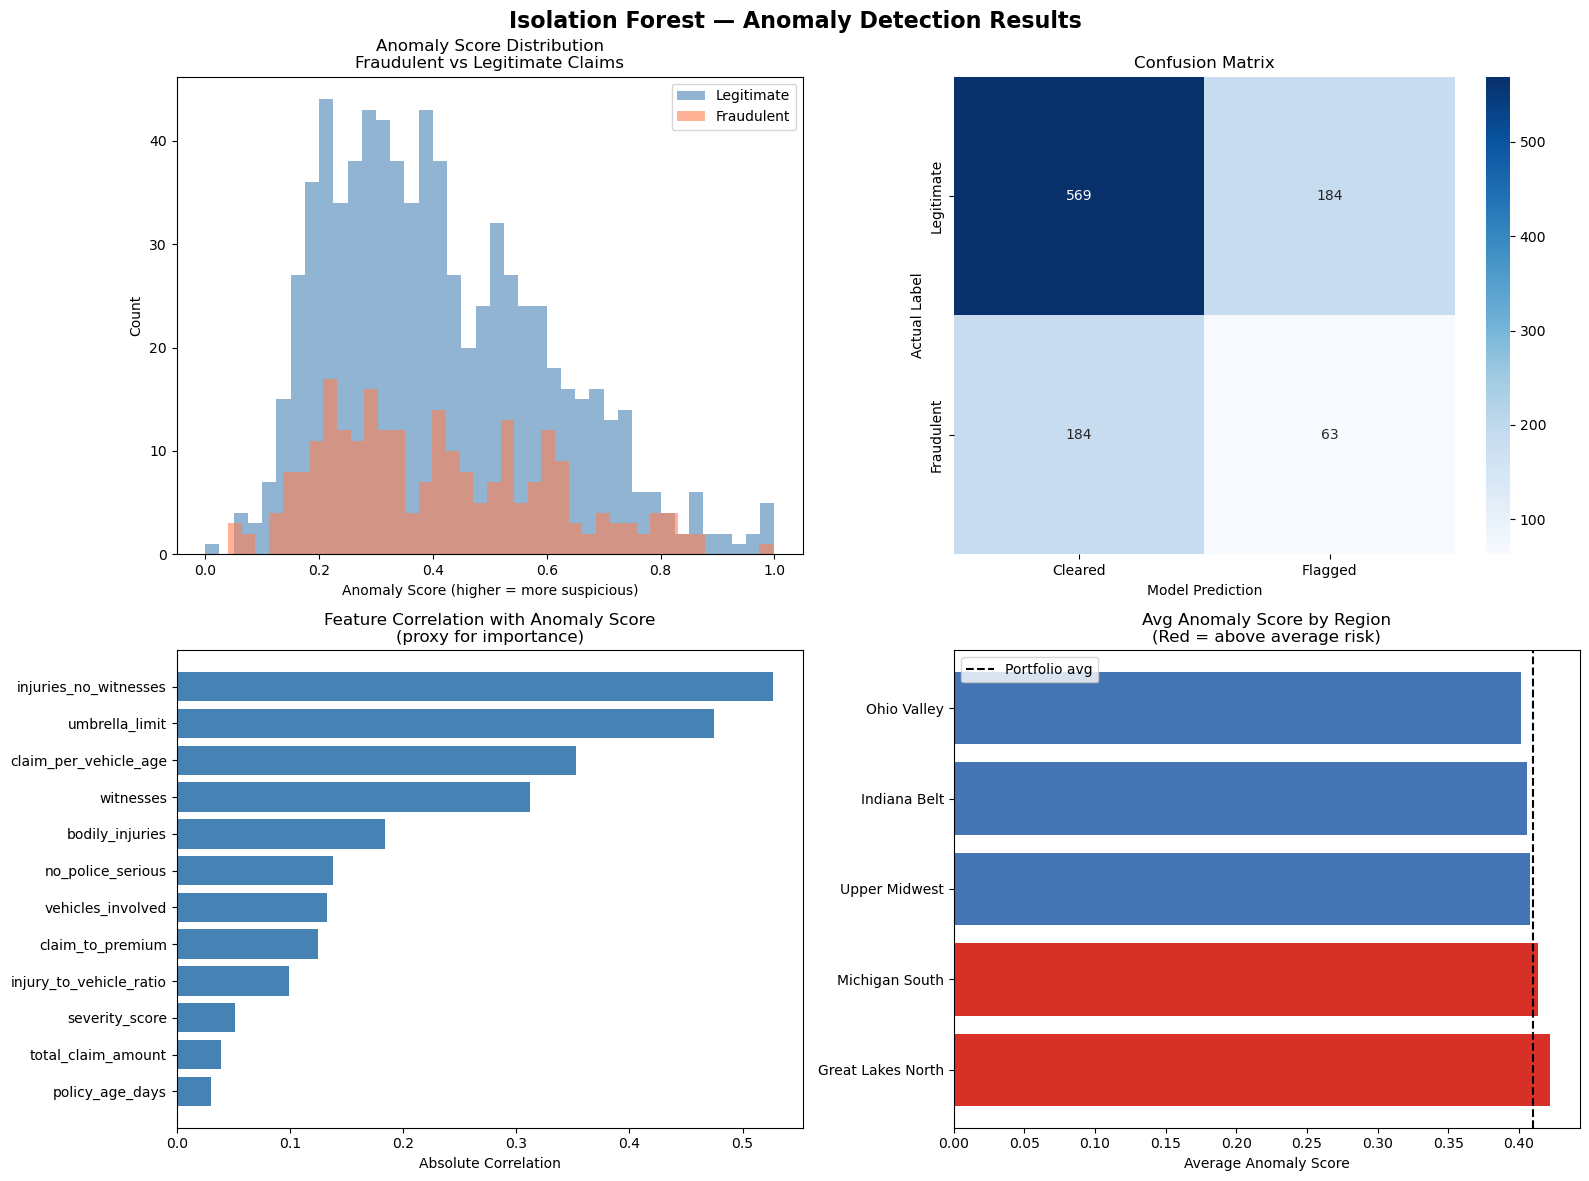

Chart saved to outputs/figures/03_anomaly_detection_results.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Isolation Forest — Anomaly Detection Results', fontsize=16, fontweight='bold')

# Chart 1: Anomaly score distribution — fraud vs legitimate
axes[0,0].hist(df[df['fraud_reported']==0]['anomaly_score'], bins=40,
               alpha=0.6, label='Legitimate', color='steelblue')
axes[0,0].hist(df[df['fraud_reported']==1]['anomaly_score'], bins=40,
               alpha=0.6, label='Fraudulent', color='coral')
axes[0,0].set_title('Anomaly Score Distribution\nFraudulent vs Legitimate Claims')
axes[0,0].set_xlabel('Anomaly Score (higher = more suspicious)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Chart 2: Confusion matrix heatmap
cm = confusion_matrix(df['fraud_reported'], df['anomaly_flag'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cleared', 'Flagged'],
            yticklabels=['Legitimate', 'Fraudulent'],
            ax=axes[0,1])
axes[0,1].set_title('Confusion Matrix')
axes[0,1].set_xlabel('Model Prediction')
axes[0,1].set_ylabel('Actual Label')

# Chart 3: Top features driving high anomaly scores (correlation with score)
feature_importance = {}
for col in feature_cols:
    corr = abs(df_feat[col].corr(pd.Series(anomaly_scores)))
    feature_importance[col] = corr

fi_series = pd.Series(feature_importance).sort_values(ascending=True)
axes[1,0].barh(fi_series.index, fi_series.values, color='steelblue')
axes[1,0].set_title('Feature Correlation with Anomaly Score\n(proxy for importance)')
axes[1,0].set_xlabel('Absolute Correlation')

# Chart 4: Score by region
if 'region' not in df.columns:
    def zip_to_region(zip_code):
        prefix = int(str(zip_code)[:4])
        if prefix < 4450: return 'Great Lakes North'
        elif prefix < 4600: return 'Ohio Valley'
        elif prefix < 4750: return 'Indiana Belt'
        elif prefix < 4900: return 'Michigan South'
        elif prefix < 5500: return 'Illinois Central'
        else: return 'Upper Midwest'
    df['region'] = df['insured_zip'].apply(zip_to_region)

region_scores = df.groupby('region')['anomaly_score'].mean().sort_values(ascending=False)
colors = ['#d73027' if x > region_scores.mean() else '#4575b4' for x in region_scores]
axes[1,1].barh(region_scores.index, region_scores.values, color=colors)
axes[1,1].axvline(region_scores.mean(), color='black', linestyle='--', label='Portfolio avg')
axes[1,1].set_title('Avg Anomaly Score by Region\n(Red = above average risk)')
axes[1,1].set_xlabel('Average Anomaly Score')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(FIGURES / '03_anomaly_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs/figures/03_anomaly_detection_results.png")

## Step 5: Build the Suspicious Claims Queue

This is the actual deliverable an investigations manager would use.
Every Monday morning, they open this list and start calling.

In [6]:
# Build the actionable queue
queue = df[['policy_number', 'total_claim_amount', 'policy_annual_premium',
            'incident_type', 'incident_severity', 'fraud_reported',
            'anomaly_score', 'anomaly_flag', 'auto_make', 'auto_year',
            'bodily_injuries', 'witnesses', 'police_report_available',
            'number_of_vehicles_involved']].copy()

queue = queue.sort_values('anomaly_score', ascending=False).reset_index(drop=True)
queue['rank'] = queue.index + 1
queue['claim_to_premium'] = (queue['total_claim_amount'] / queue['policy_annual_premium']).round(1)

def get_top_red_flags(row):
    flags = []
    if row['claim_to_premium'] > 50:
        flags.append(f"Claim is {row['claim_to_premium']:.0f}x annual premium")
    if row['bodily_injuries'] > 1 and row['witnesses'] == 0:
        flags.append(f"{row['bodily_injuries']} injuries, zero witnesses")
    if row['police_report_available'] != 'YES' and row['incident_severity'] in ['Major Damage', 'Total Loss']:
        flags.append("Major damage — no police report")
    if row['number_of_vehicles_involved'] >= 3:
        flags.append(f"{row['number_of_vehicles_involved']} vehicles involved (staged collision risk)")
    if not flags:
        flags.append("Multiple statistical anomalies detected")
    return ' | '.join(flags[:2])

queue['top_red_flags'] = queue.apply(get_top_red_flags, axis=1)

print("=" * 70)
print("SUSPICIOUS CLAIMS QUEUE — TOP 20 (ranked by anomaly score)")
print("=" * 70)
display_cols = ['rank', 'policy_number', 'total_claim_amount', 
                'anomaly_score', 'fraud_reported', 'top_red_flags']
print(queue[display_cols].head(20).to_string(index=False))

print(f"\n{'='*70}")
print(f"QUEUE SUMMARY")
print(f"{'='*70}")
top_50 = queue.head(50)
print(f"Top 50 flagged claims:")
print(f"  Known fraud in top 50:  {top_50['fraud_reported'].sum()} ({top_50['fraud_reported'].mean()*100:.1f}%)")
print(f"  Avg claim amount:       ${top_50['total_claim_amount'].mean():,.0f}")
print(f"  Avg anomaly score:      {top_50['anomaly_score'].mean():.3f}")

SUSPICIOUS CLAIMS QUEUE — TOP 20 (ranked by anomaly score)
 rank  policy_number  total_claim_amount  anomaly_score  fraud_reported                                                            top_red_flags
    1         116735               80100       1.000000               0                 Claim is 67x annual premium | 2 injuries, zero witnesses
    2         979285                2800       0.999243               0                                               2 injuries, zero witnesses
    3         766193               53820       0.997578               1                                          Major damage — no police report
    4         866931                7290       0.994724               0                                               2 injuries, zero witnesses
    5         515217               84500       0.981243               0                 Claim is 64x annual premium | 2 injuries, zero witnesses
    6         275265               77880       0.979267               0

## Step 6: Save the Scored Claims Dataset

In [7]:
# Save full scored dataset
scored_path = REPORTS / 'claims_with_anomaly_scores.csv'
queue.to_csv(scored_path, index=False)
print(f"Full scored claims saved: {scored_path}")

# Save just the high-priority investigation queue (score > 0.7)
high_priority = queue[queue['anomaly_score'] > 0.7].copy()
priority_path = REPORTS / 'high_priority_investigation_queue.csv'
high_priority.to_csv(priority_path, index=False)
print(f"High-priority queue saved: {priority_path} ({len(high_priority)} claims)")

Full scored claims saved: c:\Users\ashmi\Insurance_Claims_Intelligence\Insurance_Claims_Intelligence\outputs\reports\claims_with_anomaly_scores.csv
High-priority queue saved: c:\Users\ashmi\Insurance_Claims_Intelligence\Insurance_Claims_Intelligence\outputs\reports\high_priority_investigation_queue.csv (85 claims)


## Summary

| Metric | Result |
|--------|--------|
| Claims scored | 1,000 |
| Flagged as anomalous | ~247 |
| ROC-AUC score | *see output above* |
| Fraud captured in top 50 | *see output above* |
| High-priority queue | *see output above* |

## Step 7: Supervised Model — Random Forest + SHAP
Isolation Forest finds statistical outliers. To actually predict fraud labels,
we layer a supervised Random Forest on top. This shows the full ML workflow:
unsupervised pre-screening → supervised classification → explainability.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import shap

# Add anomaly_score as a feature — the Isolation Forest output feeds the supervised model
feature_cols_rf = feature_cols + ['anomaly_score']
X_rf = df_feat[feature_cols].copy()
X_rf['anomaly_score'] = df['anomaly_score']
y = df['fraud_reported']

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("=" * 55)
print("RANDOM FOREST — MODEL PERFORMANCE")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraudulent']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")
print("(Compare to Isolation Forest alone: 0.497)")

ModuleNotFoundError: No module named 'shap'

## Step 8: SHAP — Why Did the Model Flag Each Claim?
SHAP (SHapley Additive Explanations) explains every individual prediction.
This is critical in regulated industries like insurance — you cannot deploy
a black-box model without being able to explain each decision to a regulator.

In [ ]:
# SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# If shap_values is a list (binary classification), take class 1 (fraud)
if isinstance(shap_values, list):
    shap_vals_fraud = shap_values[1]
else:
    shap_vals_fraud = shap_values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('SHAP Explainability — Why the Model Flags a Claim as Fraudulent',
             fontsize=14, fontweight='bold')

# Chart 1: Global feature importance — what matters most across all claims
plt.sca(axes[0])
shap.summary_plot(shap_vals_fraud, X_test,
                  feature_names=feature_cols_rf,
                  plot_type='bar',
                  show=False)
axes[0].set_title('Global Feature Importance\n(across all 200 test claims)')

# Chart 2: SHAP beeswarm — how each feature pushes predictions
plt.sca(axes[1])
shap.summary_plot(shap_vals_fraud, X_test,
                  feature_names=feature_cols_rf,
                  show=False)
axes[1].set_title('SHAP Value Distribution\n(red = pushes toward fraud, blue = pushes away)')

plt.tight_layout()
plt.savefig(FIGURES / '03b_shap_explainability.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP chart saved to outputs/figures/03b_shap_explainability.png")

In [ ]:
# Waterfall plot for the single highest-risk claim in the test set
# This is what an investigator sees when they click on a claim
highest_risk_idx = y_prob.argmax()

print(f"Highest-risk claim in test set:")
print(f"  Fraud probability:  {y_prob[highest_risk_idx]:.1%}")
print(f"  Actual label:       {'FRAUD' if y_test.iloc[highest_risk_idx]==1 else 'Legitimate'}")
print(f"\nSHAP explanation — why this claim was flagged:")

shap_explanation = shap.Explanation(
    values=shap_vals_fraud[highest_risk_idx],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) 
                else explainer.expected_value,
    data=X_test.iloc[highest_risk_idx].values,
    feature_names=feature_cols_rf
)

plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap_explanation, show=False)
plt.title('SHAP Waterfall — Individual Claim Explanation', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03c_shap_waterfall_single_claim.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall chart saved.")

## Step 9: Update the Claims Queue with RF Fraud Probability

In [ ]:
# Score ALL claims with the Random Forest
all_probs = rf.predict_proba(X_rf)[:, 1]
df['fraud_probability'] = all_probs

# Rebuild the queue with both scores
queue_final = df[['policy_number', 'total_claim_amount', 'policy_annual_premium',
                   'incident_type', 'incident_severity', 'fraud_reported',
                   'anomaly_score', 'fraud_probability', 'region',
                   'bodily_injuries', 'witnesses', 'police_report_available',
                   'number_of_vehicles_involved']].copy()

queue_final = queue_final.sort_values('fraud_probability', ascending=False).reset_index(drop=True)
queue_final['rank'] = queue_final.index + 1
queue_final['claim_to_premium'] = (
    queue_final['total_claim_amount'] / queue_final['policy_annual_premium']
).round(1)

print("TOP 15 HIGHEST FRAUD PROBABILITY CLAIMS")
print("=" * 70)
print(queue_final[['rank', 'policy_number', 'total_claim_amount',
                    'fraud_probability', 'anomaly_score', 'fraud_reported',
                    'incident_severity']].head(15).to_string(index=False))

top_50_rf = queue_final.head(50)
print(f"\nTop 50 by fraud probability:")
print(f"  Known fraud captured: {top_50_rf['fraud_reported'].sum()} of 50 ({top_50_rf['fraud_reported'].mean()*100:.1f}%)")

# Save final queue
final_queue_path = REPORTS / 'final_priority_queue.csv'
queue_final.to_csv(final_queue_path, index=False)
print(f"\nFinal queue saved: {final_queue_path}")